In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

df = pd.read_csv('players_data_light-2024_2025.csv')
print(df.shape)
df.head()

(2854, 165)


,Rk,Player,Nation,Pos,Squad,Comp,Age,Born,MP,Starts,...,Att (GK),Thr,Launch%,AvgLen,Opp,Stp,Stp%,#OPA,#OPA/90,AvgDist
0,1,Max Aarons,eng ENG,DF,Bournemouth,eng Premier League,24.0,2000.0,3,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,Max Aarons,eng ENG,"DF,MF",Valencia,es La Liga,24.0,2000.0,4,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,Rodrigo Abajas,es ESP,DF,Valencia,es La Liga,21.0,2003.0,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,James Abankwah,ie IRL,"DF,MF",Udinese,it Serie A,20.0,2004.0,6,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,Keyliane Abdallah,fr FRA,FW,Marseille,fr Ligue 1,18.0,2006.0,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [2]:
df.describe()

,Rk,Age,Born,MP,Starts,Min,90s,Gls,Ast,G+A,...,Att (GK),Thr,Launch%,AvgLen,Opp,Stp,Stp%,#OPA,#OPA/90,AvgDist
count,2854.000000,2846.000000,2846.000000,2854.000000,2854.000000,2854.000000,2854.000000,2854.000000,2854.000000,2854.000000,...,212.000000,212.00000,212.000000,212.000000,212.000000,212.000000,211.000000,212.000000,212.000000,208.000000
mean,1427.500000,25.018974,1998.637034,19.012964,13.497547,1211.529082,13.460792,1.682901,1.200771,2.883672,...,491.603774,69.45283,34.138208,33.037264,226.561321,14.377358,6.159716,18.768868,1.164528,13.908654
std,824.023159,4.491624,4.497922,11.502122,11.322991,965.191628,10.724564,3.152732,1.946170,4.530513,...,410.272587,57.99046,14.239612,6.066525,187.816491,13.874832,4.074863,18.276921,1.008750,3.734229
min,1.000000,15.000000,1982.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,0.00000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
25%,714.250000,22.000000,1996.000000,9.000000,3.000000,317.250000,3.500000,0.000000,0.000000,0.000000,...,112.250000,15.75000,25.450000,29.475000,55.750000,2.000000,4.000000,3.000000,0.670000,11.975000
50%,1427.500000,25.000000,1999.000000,20.000000,11.000000,1052.500000,11.700000,0.000000,0.000000,1.000000,...,397.500000,55.00000,33.200000,32.450000,175.500000,10.500000,5.600000,14.000000,1.000000,13.700000
75%,2140.750000,28.000000,2002.000000,30.000000,23.000000,1996.750000,22.200000,2.000000,2.000000,4.000000,...,847.250000,120.25000,41.025000,35.900000,408.000000,22.000000,7.900000,30.250000,1.470000,15.525000
max,2854.000000,41.000000,2008.000000,38.000000,38.000000,3420.000000,38.000000,31.000000,18.000000,47.000000,...,1498.000000,197.00000,92.300000,56.300000,710.000000,64.000000,33.300000,89.000000,10.000000,28.000000


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2854 entries, 0 to 2853
Columns: 165 entries, Rk to AvgDist
dtypes: float64(61), int64(99), object(5)
memory usage: 3.6+ MB


In [4]:
df.isnull().sum()

Rk            0
Player        0
Nation        7
Pos           0
Squad         0
           ... 
Stp        2642
Stp%       2643
#OPA       2642
#OPA/90    2642
AvgDist    2646
Length: 165, dtype: int64

In [5]:
redundant_pattern = re.compile(r'^(Rk|Nation|Pos|Comp|Age|Born|90s|MP|Min|Starts|Gls|Ast|CrdY|CrdR|xG|PK|PKatt|TklW|Int|Crs|Off|Fld)_stats_.+$')
cols_to_drop = [c for c in df.columns if redundant_pattern.match(c)]
df = df.drop(columns=cols_to_drop)
print(f"Columns after dropping redundant: {len(df.columns)}")

Columns after dropping redundant: 153


In [6]:
null_thresh = 0.90
mostly_null = [c for c in df.columns if df[c].isnull().mean() > null_thresh]
df = df.drop(columns=mostly_null)
print(f"Columns after dropping nulls: {len(df.columns)}")

Columns after dropping nulls: 123


In [7]:
# "eng ENG" → "ENG"
df['Nation'] = df['Nation'].str.extract(r'([A-Z]{3})$')

# "eng Premier League" → "Premier League"
df['Comp'] = df['Comp'].str.replace(r'^[a-z]+\s', '', regex=True)

df[['Nation', 'Comp']].head()

,Nation,Comp
0,ENG,Premier League
1,ENG,La Liga
2,ESP,La Liga
3,IRL,Serie A
4,FRA,Ligue 1


In [8]:
num_cols = df.select_dtypes(include='number').columns
df[num_cols] = df[num_cols].fillna(0)
df = df.dropna(subset=['Player'])
print(df.shape)

(2854, 123)


In [9]:
df.to_csv('players_cleaned.csv', index=False)
print("Saved successfully!")

Saved successfully!


In [10]:
# Players with 2 clubs this season appear twice
# We keep the row with fewest minutes = their latest/new club
print("Duplicate player rows before:", df.duplicated(subset=['Player']).sum())

df = df.sort_values('Min', ascending=True)        # least minutes first
df = df.drop_duplicates(subset=['Player'], keep='first')  # keep latest club
df = df.reset_index(drop=True)

print("Duplicate player rows after:", df.duplicated(subset=['Player']).sum())
print("Final dataset shape:", df.shape)

Duplicate player rows before: 152
Duplicate player rows after: 0
Final dataset shape: (2702, 123)


In [11]:
print(df.columns.tolist())

['Rk', 'Player', 'Nation', 'Pos', 'Squad', 'Comp', 'Age', 'Born', 'MP', 'Starts', 'Min', '90s', 'Gls', 'Ast', 'G+A', 'G-PK', 'PK', 'PKatt', 'CrdY', 'CrdR', 'xG', 'npxG', 'xAG', 'npxG+xAG', 'G+A-PK', 'xG+xAG', 'PrgC', 'PrgP', 'PrgR', 'Sh', 'SoT', 'SoT%', 'Sh/90', 'SoT/90', 'G/Sh', 'G/SoT', 'Dist', 'FK', 'npxG_stats_shooting', 'npxG/Sh', 'G-xG', 'np:G-xG', 'Cmp', 'Att', 'Cmp%', 'TotDist', 'PrgDist', 'xAG_stats_passing', 'xA', 'A-xAG', 'KP', '1/3', 'PPA', 'CrsPA', 'PrgP_stats_passing', 'Live', 'Dead', 'FK_stats_passing_types', 'TB', 'Sw', 'Crs', 'TI', 'CK', 'In', 'Out', 'Str', 'Cmp_stats_passing_types', 'Tkl', 'TklW', 'Def 3rd', 'Mid 3rd', 'Att 3rd', 'Att_stats_defense', 'Tkl%', 'Lost', 'Blocks_stats_defense', 'Sh_stats_defense', 'Pass', 'Int', 'Tkl+Int', 'Clr', 'Err', 'SCA', 'SCA90', 'PassLive', 'PassDead', 'TO', 'Sh_stats_gca', 'Fld', 'Def', 'GCA', 'GCA90', 'Touches', 'Def Pen', 'Def 3rd_stats_possession', 'Mid 3rd_stats_possession', 'Att 3rd_stats_possession', 'Att Pen', 'Live_stats_po

In [12]:
# Drop unnecessary / overly granular columns
cols_to_drop = [
    # Useless identifiers
    'Rk', 'Born',

    # Redundant derived goal stats (Gls + xG already cover these)
    'npxG', 'npxG+xAG', 'G+A-PK', 'xG+xAG', 'G-PK',
    'npxG_stats_shooting', 'npxG/Sh', 'G-xG', 'np:G-xG',

    # Shooting ratios (SoT + Gls already tell the story)
    'SoT%', 'G/Sh', 'G/SoT',

    # Distance duplicates
    'TotDist', 'PrgDist',

    # Duplicate passing columns
    'xAG_stats_passing', 'PrgP_stats_passing',

    # Overly granular pass type breakdown
    'Live', 'Dead', 'FK_stats_passing_types', 'TB', 'Sw',
    'TI', 'CK', 'In', 'Out', 'Str', 'Cmp_stats_passing_types',

    # Zonal tackle splits (Tkl total is enough)
    'Def 3rd', 'Mid 3rd', 'Att 3rd', 'Att_stats_defense',

    # Duplicate defense cols
    'Sh_stats_defense', 'PassLive', 'PassDead', 'Sh_stats_gca',

    # Zonal possession splits
    'Def Pen', 'Def 3rd_stats_possession', 'Mid 3rd_stats_possession',
    'Att 3rd_stats_possession', 'Att Pen', 'Live_stats_possession',
    'Att_stats_possession', 'TotDist_stats_possession',
    'PrgDist_stats_possession', 'PrgC_stats_possession',
    '1/3_stats_possession', 'CPA', 'Mis', 'Dis', 'PrgR_stats_possession',

    # Rare events
    '2CrdY', 'PKwon', 'PKcon', 'OG', 'Lost_stats_misc'
]

df = df.drop(columns=cols_to_drop)
print(f"Final shape: {df.shape}")  # should be (2702, 66)

Final shape: (2702, 66)


In [13]:
df.to_csv('players_cleaned.csv', index=False)
print("Saved!")

Saved!


In [14]:
#Analysis

In [15]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

df = pd.read_csv('players_cleaned.csv')
print(df.shape)
df.head()

(2702, 66)


,Player,Nation,Pos,Squad,Comp,Age,MP,Starts,Min,90s,...,Succ,Succ%,Tkld,Tkld%,Carries,Rec,Fls,Recov,Won,Won%
0,Vitor Reis,BRA,DF,Manchester City,Premier League,18.0,1,0,1,0.0,...,1,100.0,0,0.0,2,2,0,0,0,0.0
1,Remy Rees-Dottin,ENG,FW,Bournemouth,Premier League,18.0,1,0,1,0.0,...,0,0.0,0,0.0,0,0,0,0,0,0.0
2,Arijon Ibrahimović,GER,FW,Bayern Munich,Bundesliga,18.0,1,0,1,0.0,...,1,100.0,0,0.0,3,3,0,0,0,0.0
3,Will Alves,ENG,FW,Leicester City,Premier League,19.0,1,0,1,0.0,...,0,0.0,0,0.0,1,1,0,0,0,0.0
4,Anthony Briançon,FRA,DF,Saint-Étienne,Ligue 1,29.0,1,0,1,0.0,...,0,0.0,0,0.0,0,0,0,0,0,0.0


In [16]:
# FW,MF → FW | MF,DF → MF (take first part as primary)
df['Pos'] = df['Pos'].str.split(',').str[0]

print(df['Pos'].value_counts())

Pos
DF    969
MF    853
FW    672
GK    208
Name: count, dtype: int64


In [17]:
leagues = ['Premier League', 'La Liga', 'Serie A', 'Bundesliga', 'Ligue 1']
positions = ['FW', 'MF', 'DF', 'GK']

# This gives you easy access like: groups['La Liga']['FW']
groups = {}
for league in leagues:
    groups[league] = {}
    for pos in positions:
        groups[league][pos] = df[(df['Comp'] == league) & (df['Pos'] == pos)].reset_index(drop=True)

# Quick summary
for league in leagues:
    print(f"\n{league}:")
    for pos in positions:
        print(f"  {pos}: {len(groups[league][pos])} players")


Premier League:
  FW: 145 players
  MF: 164 players
  DF: 201 players
  GK: 44 players

La Liga:
  FW: 149 players
  MF: 192 players
  DF: 188 players
  GK: 44 players

Serie A:
  FW: 137 players
  MF: 183 players
  DF: 213 players
  GK: 47 players

Bundesliga:
  FW: 108 players
  MF: 150 players
  DF: 174 players
  GK: 38 players

Ligue 1:
  FW: 133 players
  MF: 164 players
  DF: 193 players
  GK: 35 players


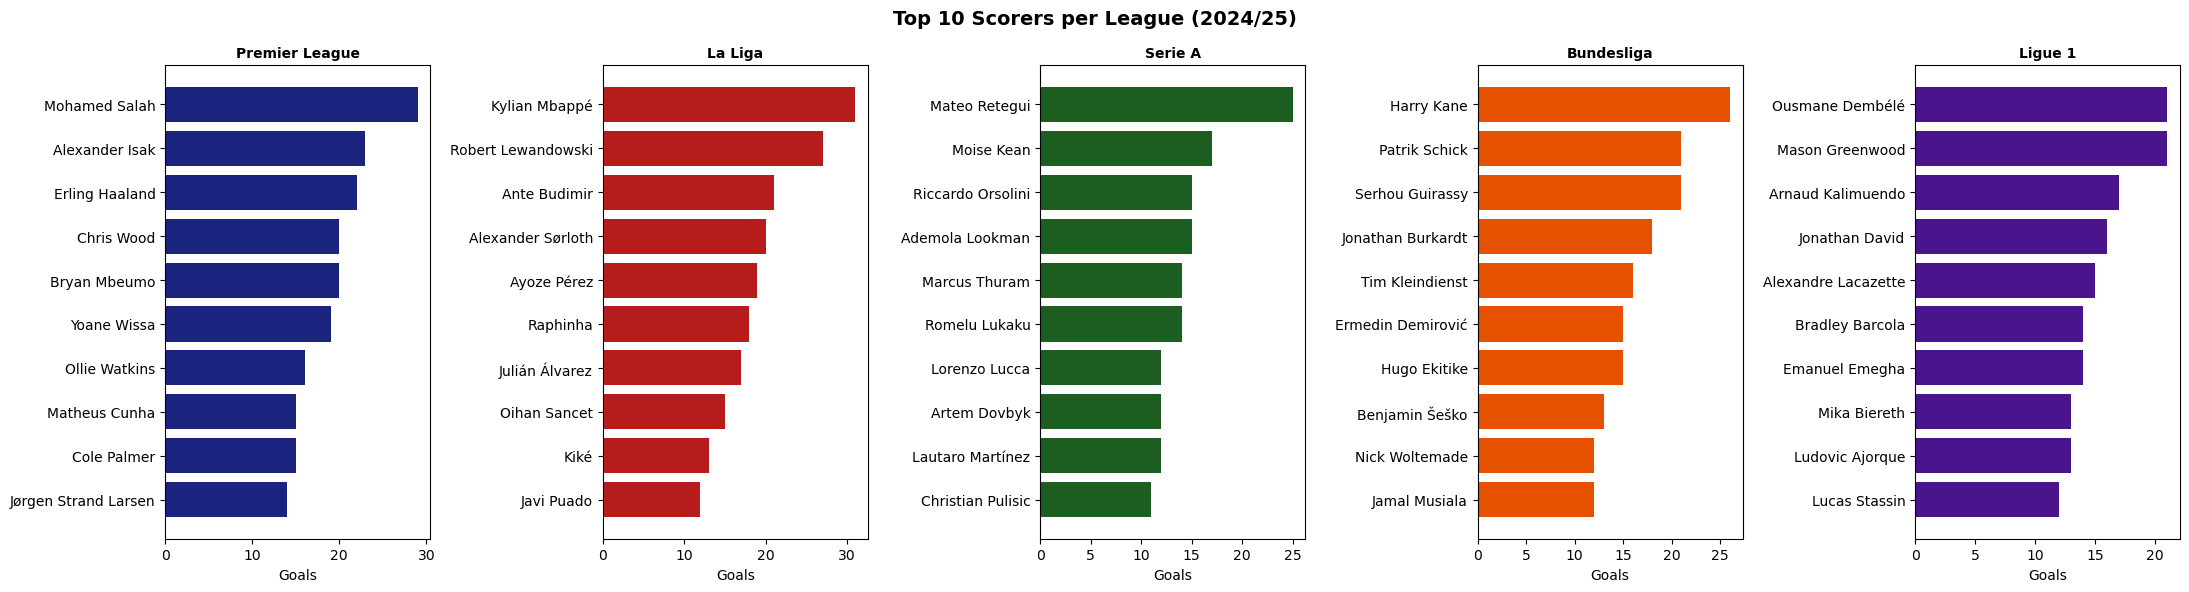

In [18]:
fig, axes = plt.subplots(1, 5, figsize=(22, 6))
colors = ['#1a237e', '#b71c1c', '#1b5e20', '#e65100', '#4a148c']

for i, league in enumerate(leagues):
    top = df[df['Comp'] == league].nlargest(10, 'Gls')[['Player', 'Gls']]
    axes[i].barh(top['Player'], top['Gls'], color=colors[i])
    axes[i].set_title(f'{league}', fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Goals')
    axes[i].invert_yaxis()

plt.suptitle('Top 10 Scorers per League (2024/25)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('top_scorers.png')
plt.show()

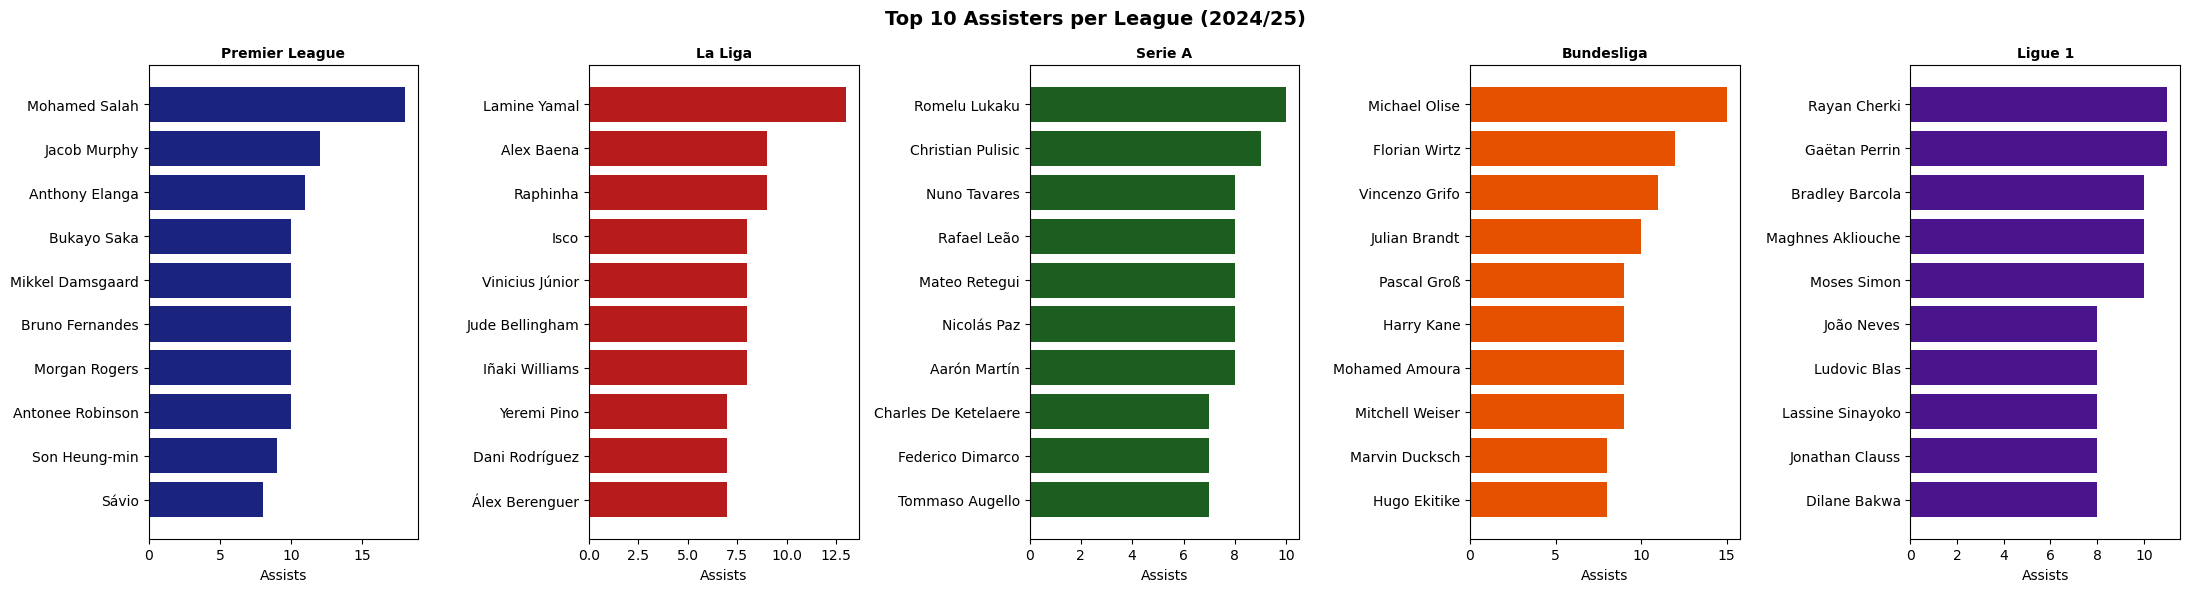

In [19]:
fig, axes = plt.subplots(1, 5, figsize=(22, 6))

for i, league in enumerate(leagues):
    top = df[df['Comp'] == league].nlargest(10, 'Ast')[['Player', 'Ast']]
    axes[i].barh(top['Player'], top['Ast'], color=colors[i])
    axes[i].set_title(f'{league}', fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Assists')
    axes[i].invert_yaxis()

plt.suptitle('Top 10 Assisters per League (2024/25)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('top_assisters.png')
plt.show()

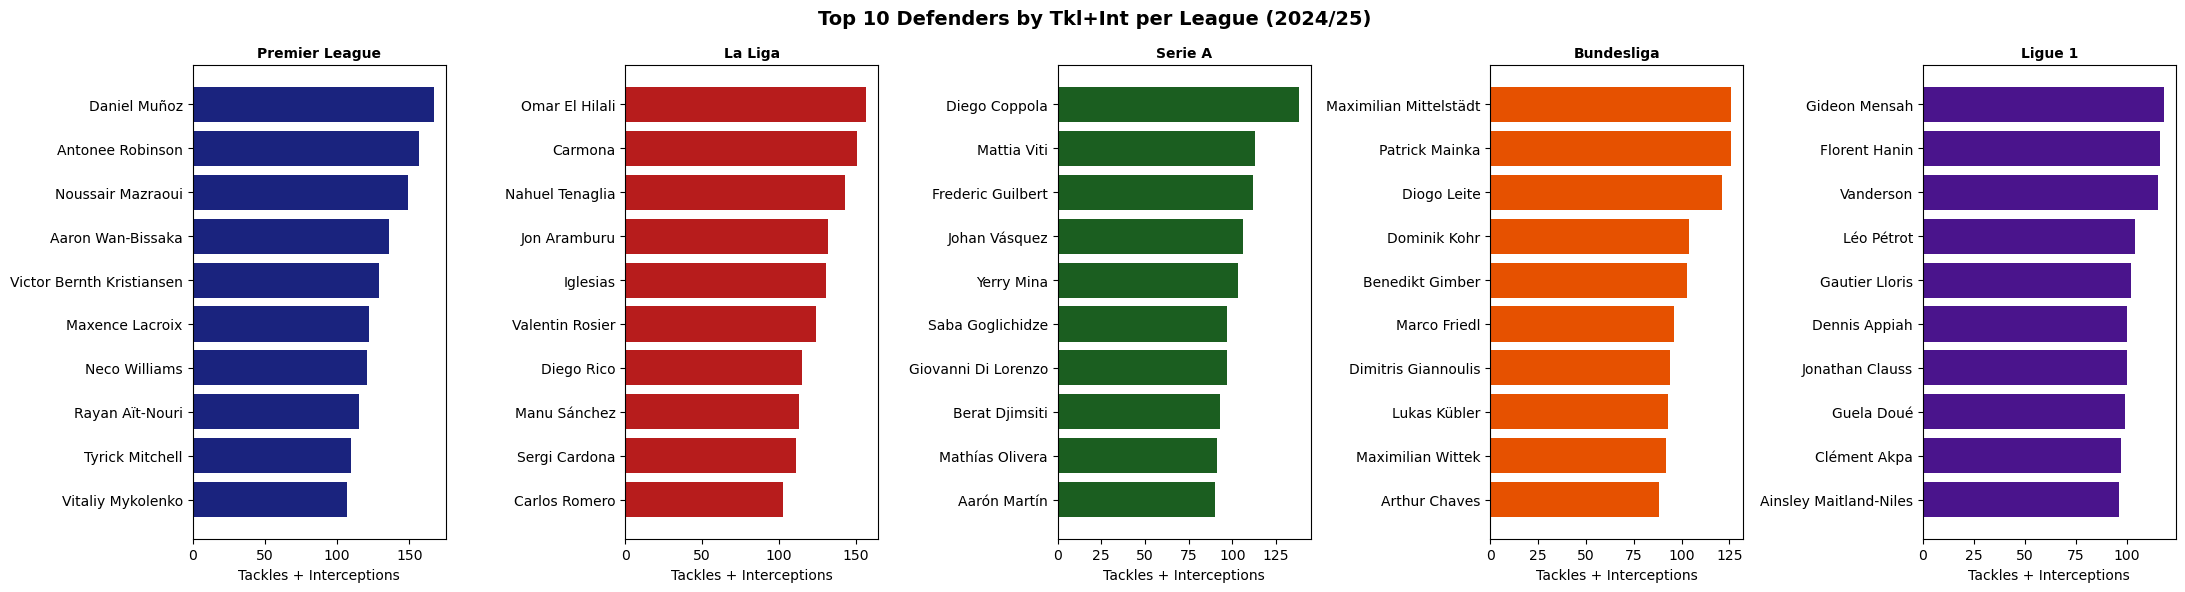

In [23]:
fig, axes = plt.subplots(1, 5, figsize=(22, 6))

for i, league in enumerate(leagues):
    top = groups[league]['DF'].nlargest(10, 'Tkl+Int')[['Player', 'Tkl+Int']]
    axes[i].barh(top['Player'], top['Tkl+Int'], color=colors[i])
    axes[i].set_title(f'{league}', fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Tackles + Interceptions')
    axes[i].invert_yaxis()

plt.suptitle('Top 10 Defenders by Tkl+Int per League (2024/25)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('top_defenders.png')
plt.show()

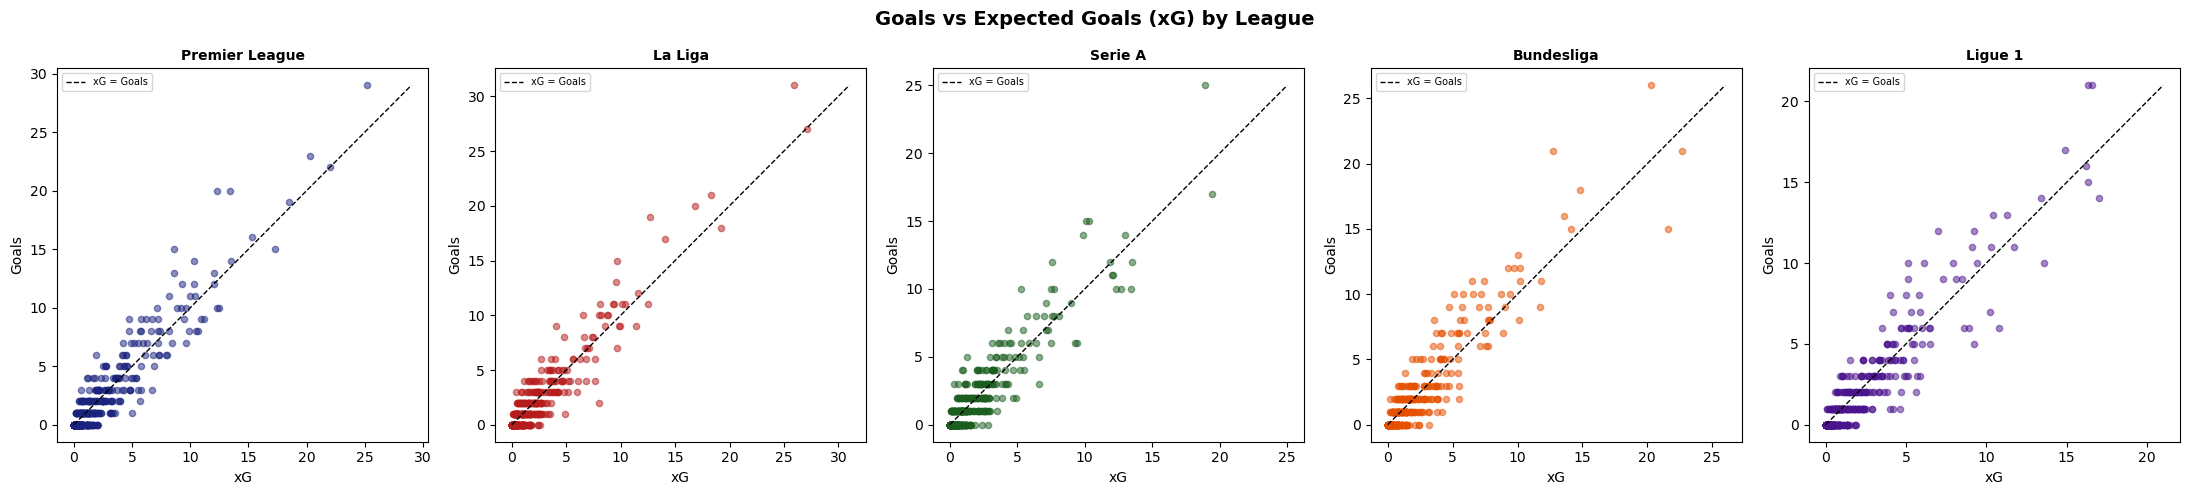

In [24]:
fig, axes = plt.subplots(1, 5, figsize=(22, 5))

for i, league in enumerate(leagues):
    sub = df[df['Comp'] == league]
    axes[i].scatter(sub['xG'], sub['Gls'], alpha=0.5, s=20, color=colors[i])
    max_val = max(sub['xG'].max(), sub['Gls'].max())
    axes[i].plot([0, max_val], [0, max_val], 'k--', linewidth=1, label='xG = Goals')
    axes[i].set_title(f'{league}', fontsize=10, fontweight='bold')
    axes[i].set_xlabel('xG')
    axes[i].set_ylabel('Goals')
    axes[i].legend(fontsize=7)

plt.suptitle('Goals vs Expected Goals (xG) by League', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('goals_vs_xg.png')
plt.show()

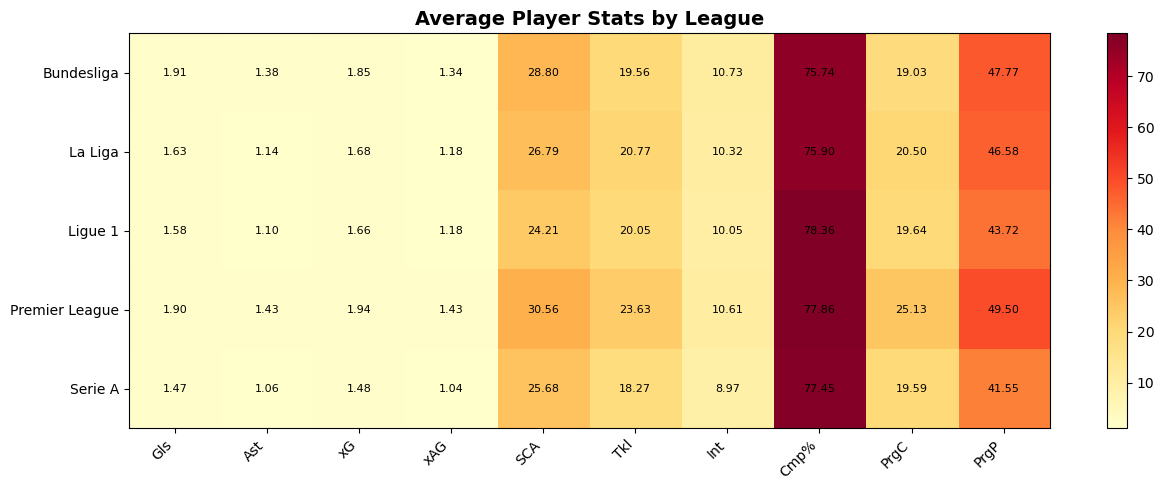

In [25]:
cols = ['Gls', 'Ast', 'xG', 'xAG', 'SCA', 'Tkl', 'Int', 'Cmp%', 'PrgC', 'PrgP']
league_avg = df.groupby('Comp')[cols].mean().round(2)

fig, ax = plt.subplots(figsize=(13, 5))
im = ax.imshow(league_avg.values, cmap='YlOrRd', aspect='auto')
plt.colorbar(im, ax=ax)

ax.set_xticks(range(len(cols)))
ax.set_xticklabels(cols, rotation=45, ha='right')
ax.set_yticks(range(len(league_avg.index)))
ax.set_yticklabels(league_avg.index)

for i in range(len(league_avg.index)):
    for j in range(len(cols)):
        ax.text(j, i, f'{league_avg.values[i, j]:.2f}',
                ha='center', va='center', fontsize=8, color='black')

ax.set_title('Average Player Stats by League', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('league_heatmap.png')
plt.show()

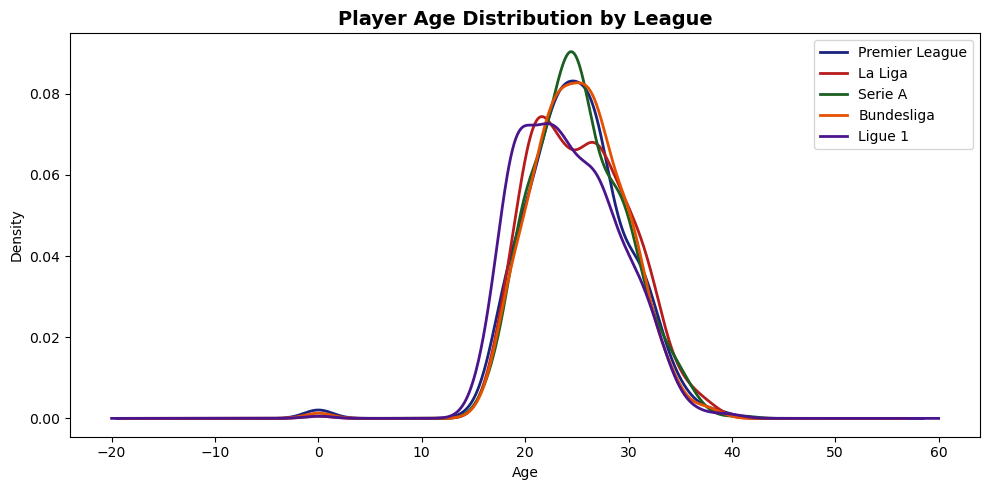

In [28]:
plt.figure(figsize=(10, 5))
for i, league in enumerate(leagues):
    sub = df[df['Comp'] == league]
    sub['Age'].plot(kind='kde', label=league, color=colors[i], linewidth=2)

plt.title('Player Age Distribution by League', fontsize=14, fontweight='bold')
plt.xlabel('Age')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.savefig('age_distribution.png')
plt.show()

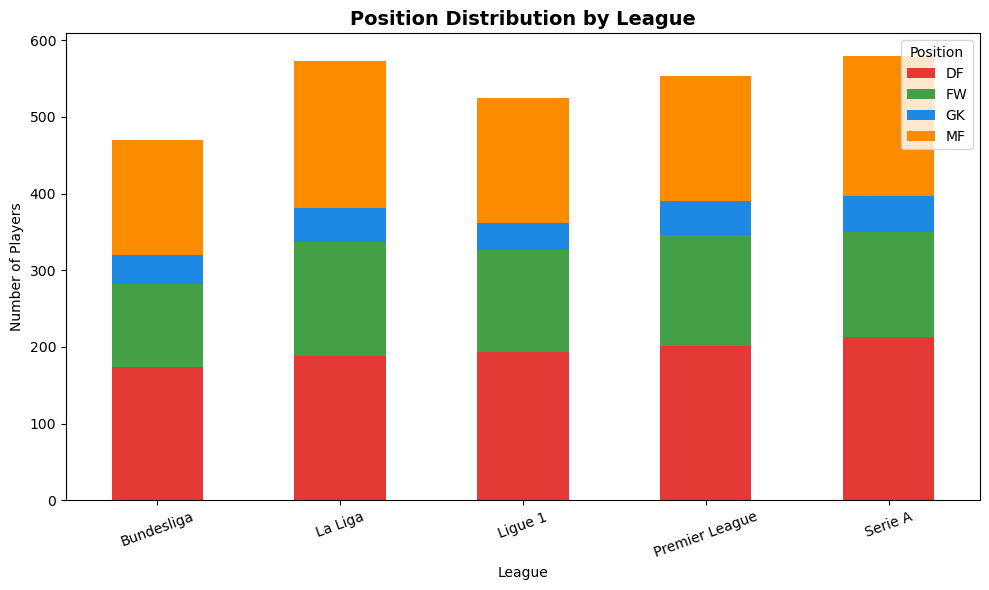

In [29]:
pos_league = df.groupby(['Comp', 'Pos']).size().unstack(fill_value=0)

pos_league.plot(kind='bar', stacked=True, figsize=(10, 6),
                color=['#e53935', '#43a047', '#1e88e5', '#fb8c00'])
plt.title('Position Distribution by League', fontsize=14, fontweight='bold')
plt.xlabel('League')
plt.ylabel('Number of Players')
plt.xticks(rotation=20)
plt.legend(title='Position')
plt.tight_layout()
plt.savefig('position_distribution.png')
plt.show()

In [30]:
# Average stats per POSITION per LEAGUE
pos_cols = ['Gls', 'Ast', 'xG', 'Tkl', 'Int', 'Cmp%', 'SCA']
for league in leagues:
    print(f"\n{'='*40}")
    print(f"{league}")
    print('='*40)
    print(df[df['Comp'] == league].groupby('Pos')[pos_cols].mean().round(2).to_string())


Premier League
      Gls   Ast    xG    Tkl    Int   Cmp%    SCA
Pos                                              
DF   0.63  0.84  0.75  27.59  15.53  82.96  21.96
FW   4.28  2.15  4.17  15.15   4.07  71.51  37.69
GK   0.00  0.20  0.00   0.64   0.23  70.80   2.91
MF   1.87  1.83  1.95  32.45  13.14  79.13  42.23

La Liga
      Gls   Ast    xG    Tkl    Int   Cmp%    SCA
Pos                                              
DF   0.55  0.74  0.62  27.45  16.15  81.51  19.56
FW   3.67  1.64  3.75  11.53   4.06  68.20  32.27
GK   0.00  0.05  0.00   0.61   0.11  70.35   2.91
MF   1.47  1.41  1.48  26.01  11.81  77.64  35.10

Serie A
      Gls   Ast    xG    Tkl    Int   Cmp%    SCA
Pos                                              
DF   0.72  0.88  0.76  24.46  14.46  81.48  21.38
FW   3.34  1.47  3.34  10.88   3.22  70.56  32.19
GK   0.00  0.02  0.00   0.13   0.09  73.03   2.81
MF   1.31  1.21  1.32  21.25   9.18  79.07  31.69

Bundesliga
      Gls   Ast    xG    Tkl    Int   Cmp%    SCA
Pos 

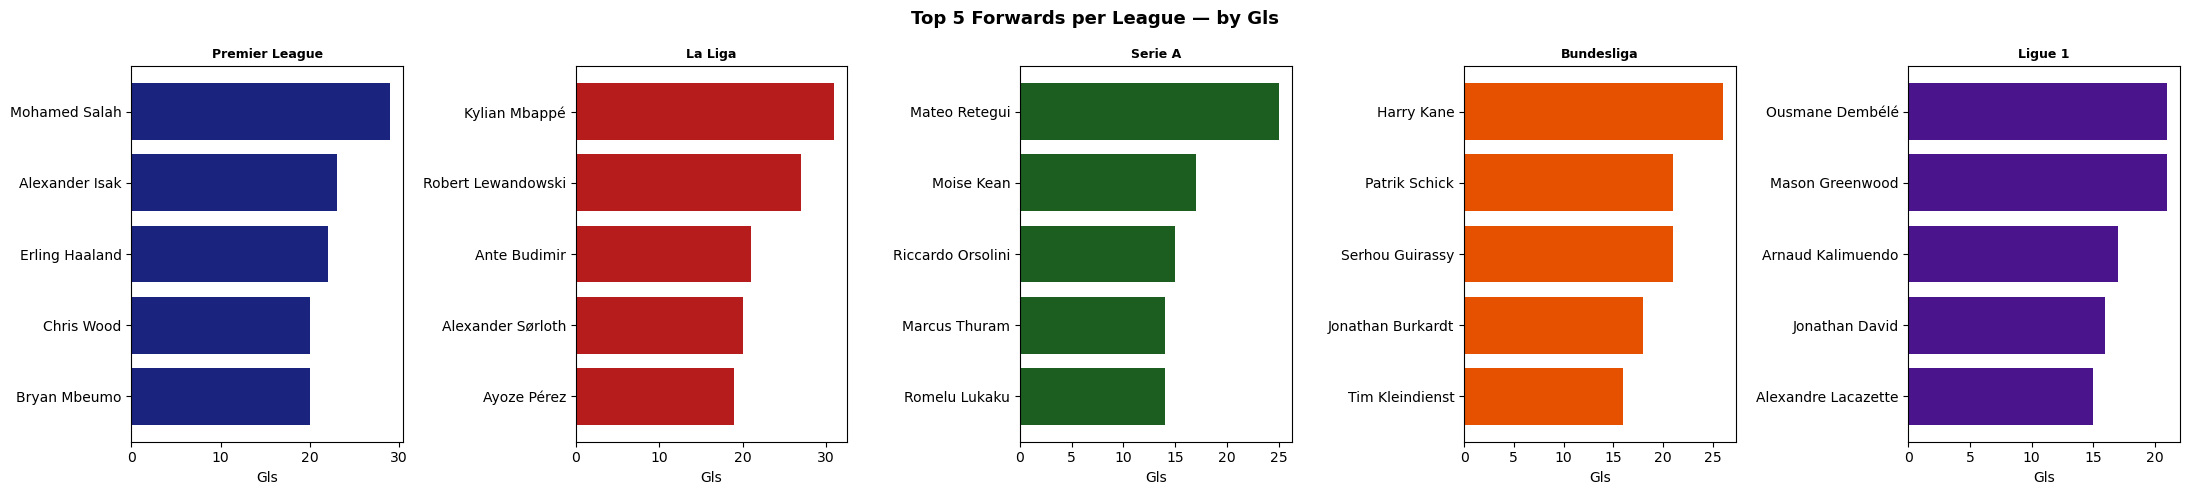

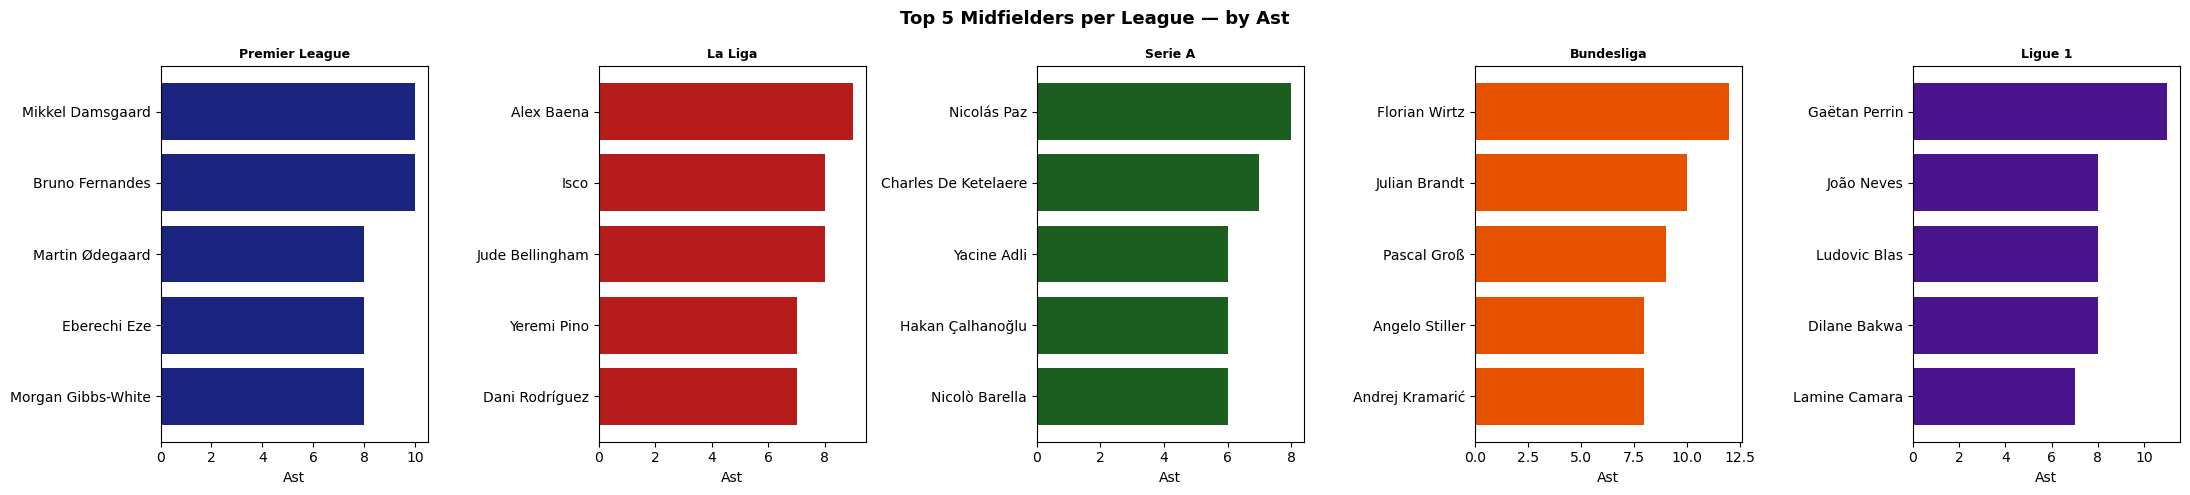

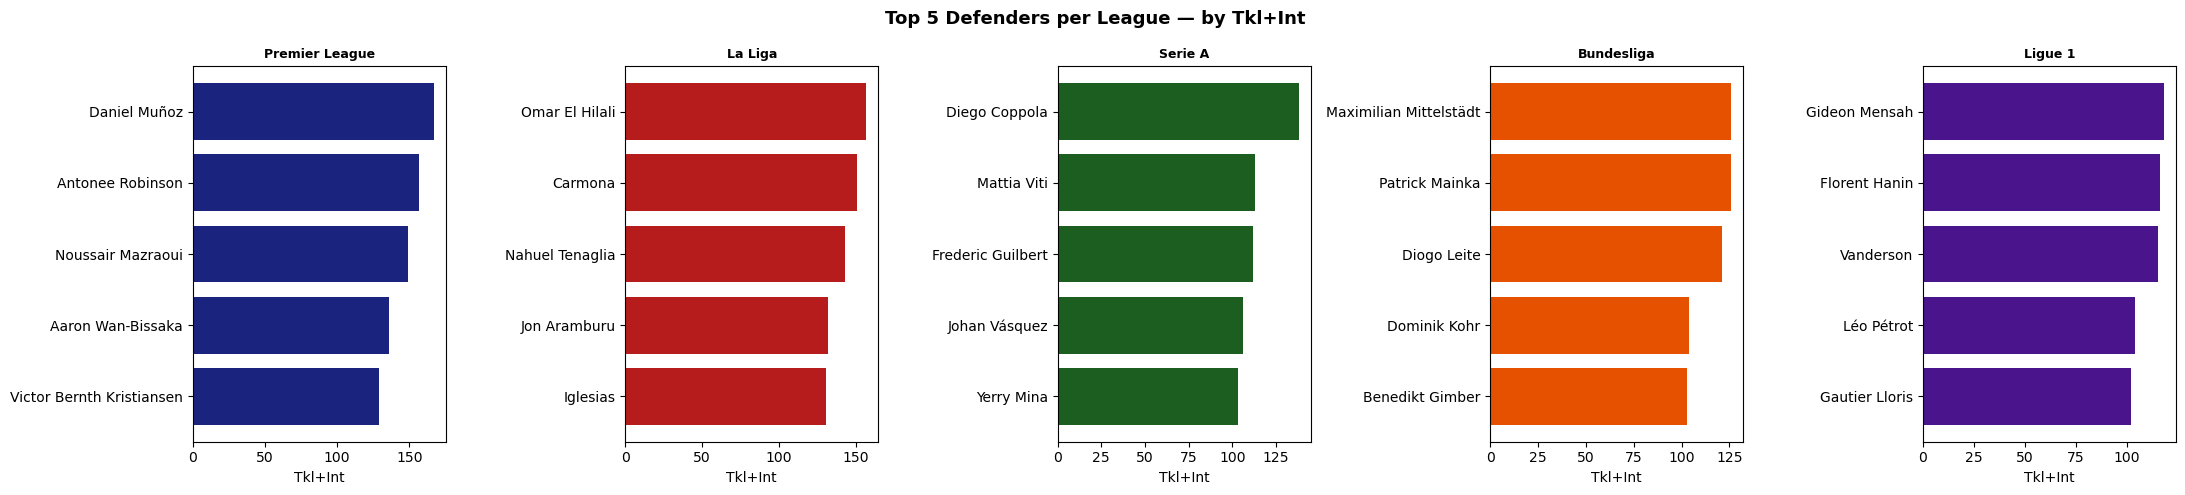

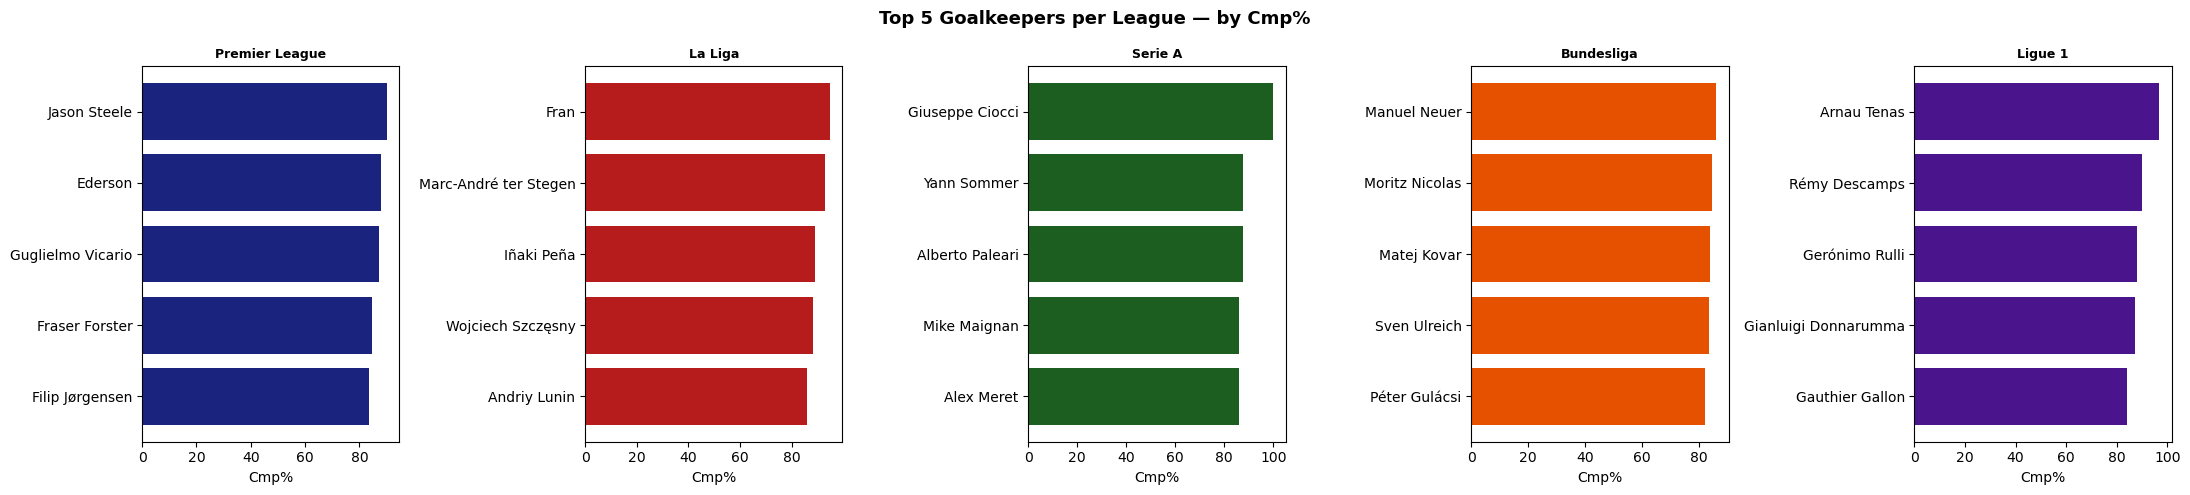

In [39]:
pos_labels = {'FW': 'Forwards', 'MF': 'Midfielders', 'DF': 'Defenders', 'GK': 'Goalkeepers'}
pos_stat = {'FW': 'Gls', 'MF': 'Ast', 'DF': 'Tkl+Int', 'GK': 'Cmp%'}

for pos in positions:
    fig, axes = plt.subplots(1, 5, figsize=(22, 5))
    for i, league in enumerate(leagues):
        top = groups[league][pos].nlargest(5, pos_stat[pos])[['Player', pos_stat[pos]]]
        axes[i].barh(top['Player'], top[pos_stat[pos]], color=colors[i])
        axes[i].set_title(f'{league}', fontsize=9, fontweight='bold')
        axes[i].set_xlabel(pos_stat[pos])
        axes[i].invert_yaxis()
    plt.suptitle(f'Top 5 {pos_labels[pos]} per League — by {pos_stat[pos]}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'top5_{pos}.png')
    plt.show()

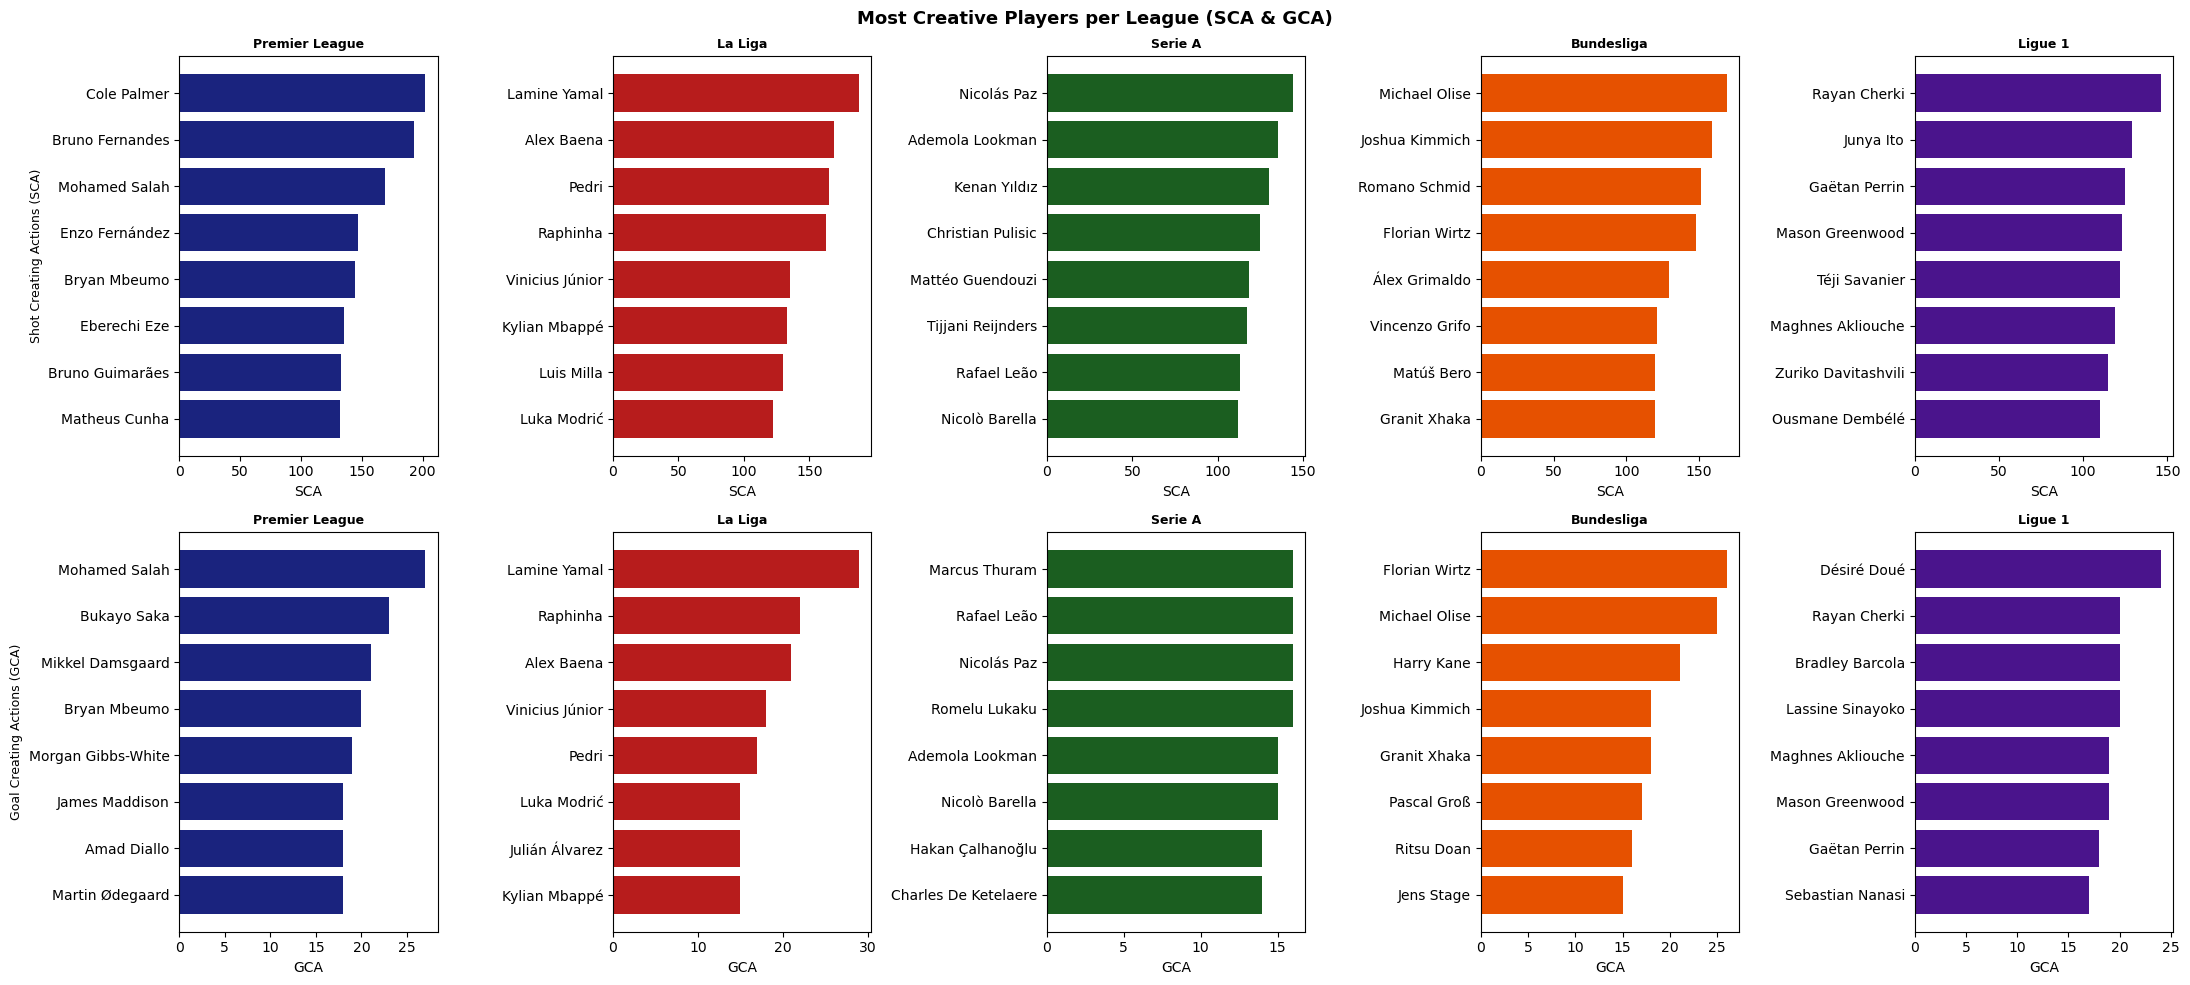

In [33]:
fig, axes = plt.subplots(2, 5, figsize=(22, 10))

for i, league in enumerate(leagues):
    # SCA
    top_sca = df[df['Comp'] == league].nlargest(8, 'SCA')[['Player', 'SCA']]
    axes[0][i].barh(top_sca['Player'], top_sca['SCA'], color=colors[i])
    axes[0][i].set_title(f'{league}', fontsize=9, fontweight='bold')
    axes[0][i].set_xlabel('SCA')
    axes[0][i].invert_yaxis()

    # GCA
    top_gca = df[df['Comp'] == league].nlargest(8, 'GCA')[['Player', 'GCA']]
    axes[1][i].barh(top_gca['Player'], top_gca['GCA'], color=colors[i])
    axes[1][i].set_title(f'{league}', fontsize=9, fontweight='bold')
    axes[1][i].set_xlabel('GCA')
    axes[1][i].invert_yaxis()

axes[0][0].set_ylabel('Shot Creating Actions (SCA)', fontsize=9)
axes[1][0].set_ylabel('Goal Creating Actions (GCA)', fontsize=9)

plt.suptitle('Most Creative Players per League (SCA & GCA)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('creative_players.png')
plt.show()

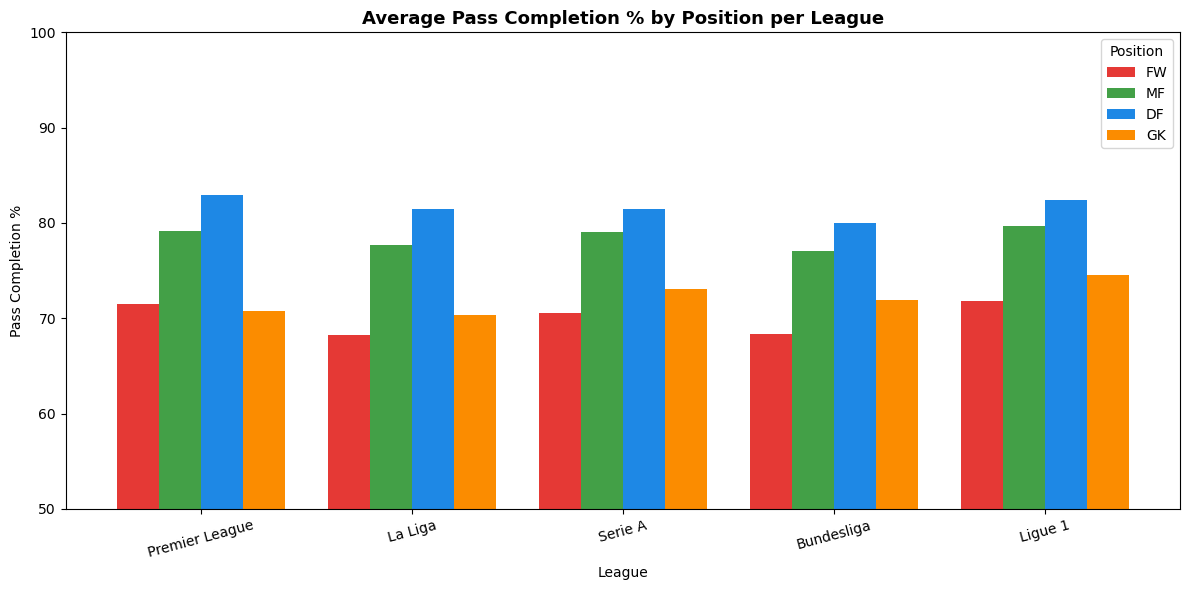

In [34]:
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(leagues))
width = 0.2
pos_colors = ['#e53935', '#43a047', '#1e88e5', '#fb8c00']

for j, pos in enumerate(positions):
    avg_cmp = []
    for league in leagues:
        val = groups[league][pos]['Cmp%'].mean()
        avg_cmp.append(round(val, 2))
    bars = ax.bar(x + j * width, avg_cmp, width, label=pos, color=pos_colors[j])

ax.set_title('Average Pass Completion % by Position per League', fontsize=13, fontweight='bold')
ax.set_xlabel('League')
ax.set_ylabel('Pass Completion %')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(leagues, rotation=15)
ax.legend(title='Position')
ax.set_ylim(50, 100)
plt.tight_layout()
plt.savefig('pass_completion_by_position.png')
plt.show()

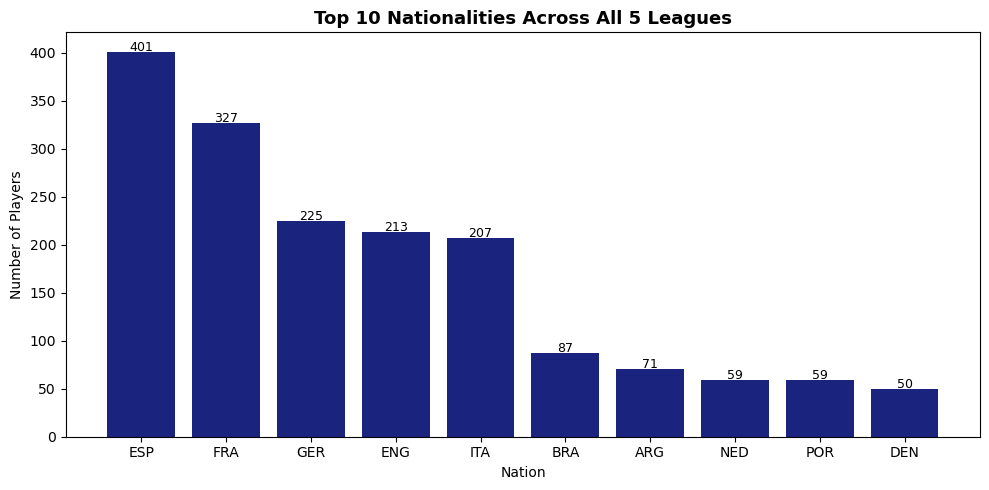

In [35]:
top_nations = df['Nation'].value_counts().head(10)

plt.figure(figsize=(10, 5))
bars = plt.bar(top_nations.index, top_nations.values, color='#1a237e')

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 1,
             str(int(bar.get_height())),
             ha='center', fontsize=9)

plt.title('Top 10 Nationalities Across All 5 Leagues', fontsize=13, fontweight='bold')
plt.xlabel('Nation')
plt.ylabel('Number of Players')
plt.tight_layout()
plt.savefig('nationality_analysis.png')
plt.show()

Total players under 21: 486


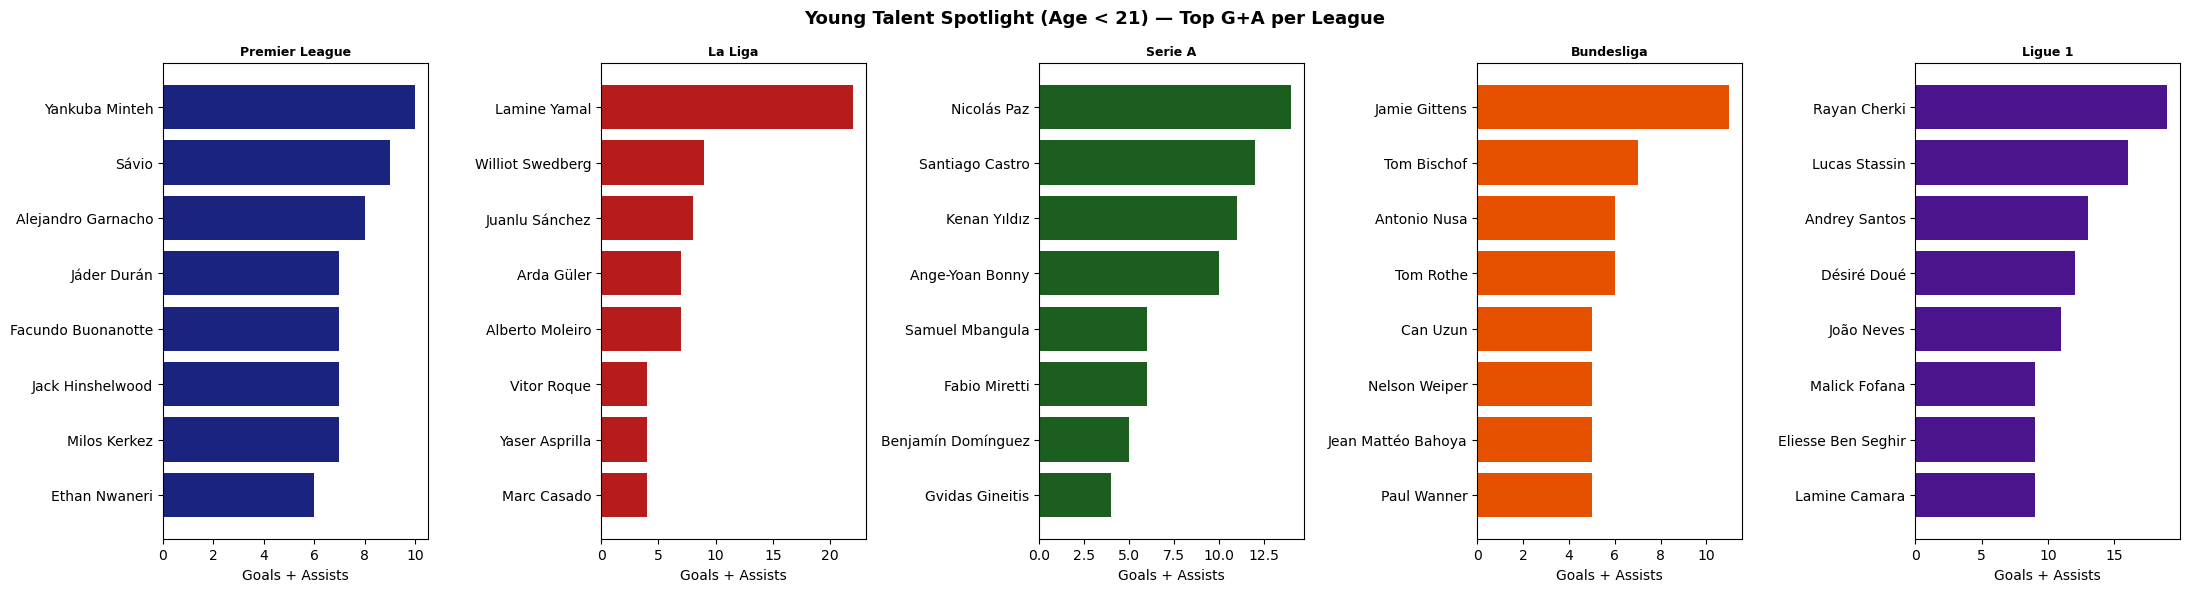

In [36]:
young = df[df['Age'] < 21].copy()
print(f"Total players under 21: {len(young)}")

fig, axes = plt.subplots(1, 5, figsize=(22, 6))

for i, league in enumerate(leagues):
    top = young[young['Comp'] == league].nlargest(8, 'G+A')[['Player', 'Age', 'G+A']]
    axes[i].barh(top['Player'], top['G+A'], color=colors[i])
    axes[i].set_title(f'{league}', fontsize=9, fontweight='bold')
    axes[i].set_xlabel('Goals + Assists')
    axes[i].invert_yaxis()

plt.suptitle('Young Talent Spotlight (Age < 21) — Top G+A per League', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('young_talent.png')
plt.show()

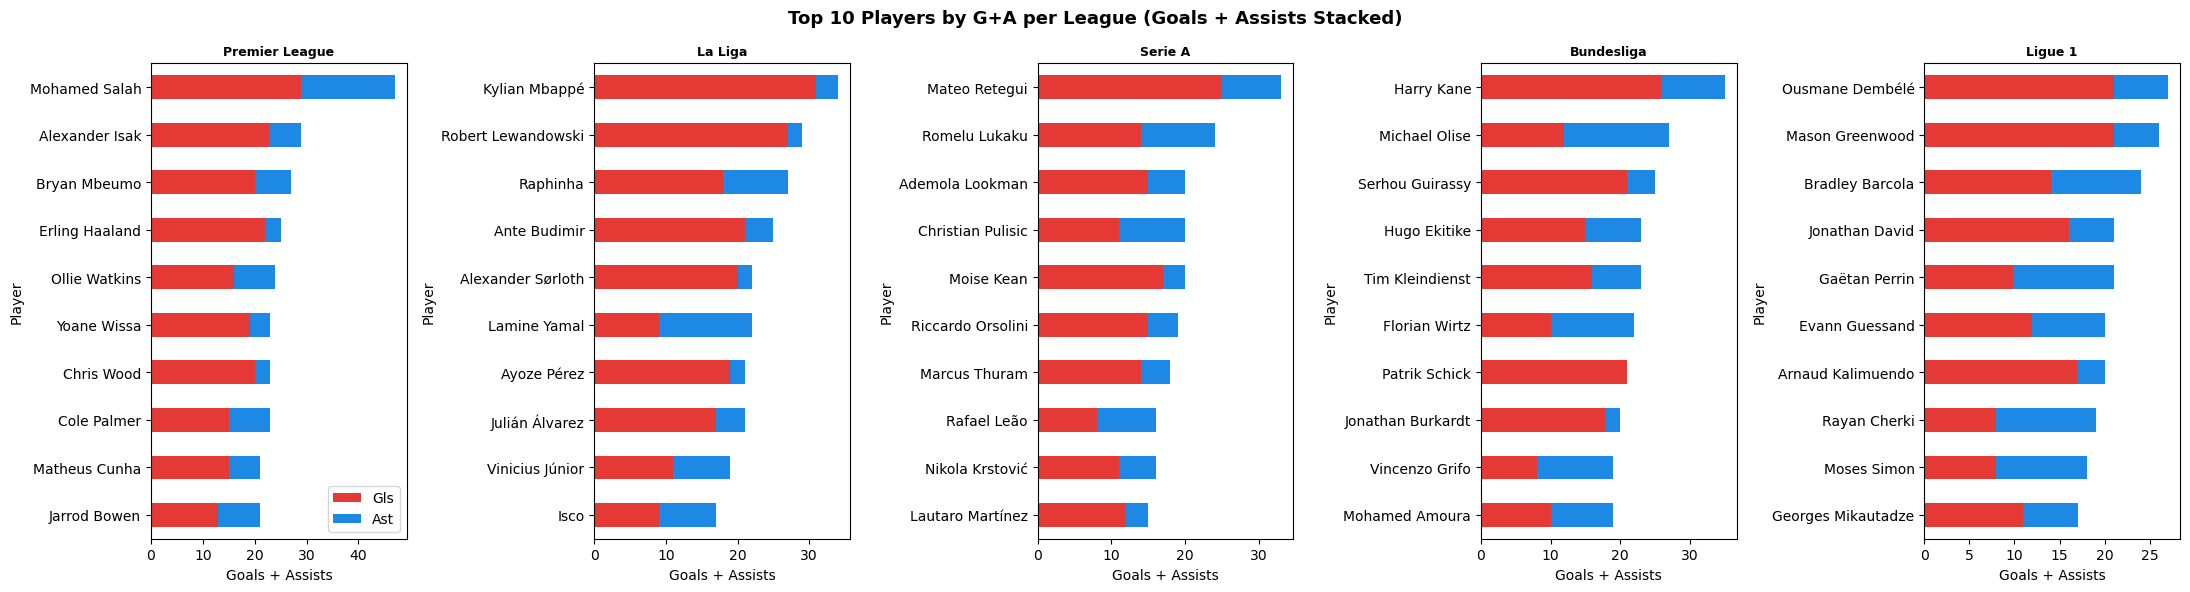

In [37]:
fig, axes = plt.subplots(1, 5, figsize=(22, 6))

for i, league in enumerate(leagues):
    top = df[df['Comp'] == league].nlargest(10, 'G+A')[['Player', 'Gls', 'Ast']]
    top = top.set_index('Player')
    top.plot(kind='barh', stacked=True, ax=axes[i],
             color=['#e53935', '#1e88e5'], legend=(i == 0))
    axes[i].set_title(f'{league}', fontsize=9, fontweight='bold')
    axes[i].set_xlabel('Goals + Assists')
    axes[i].invert_yaxis()

plt.suptitle('Top 10 Players by G+A per League (Goals + Assists Stacked)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('g_plus_a_ranking.png')
plt.show()

In [38]:
pos_cols = ['Gls', 'Ast', 'xG', 'Tkl', 'Int', 'Cmp%', 'SCA']

for league in leagues:
    print(f"\n{'='*45}")
    print(f"  {league}")
    print('='*45)
    summary = df[df['Comp'] == league].groupby('Pos')[pos_cols].mean().round(2)
    print(summary.to_string())


  Premier League
      Gls   Ast    xG    Tkl    Int   Cmp%    SCA
Pos                                              
DF   0.63  0.84  0.75  27.59  15.53  82.96  21.96
FW   4.28  2.15  4.17  15.15   4.07  71.51  37.69
GK   0.00  0.20  0.00   0.64   0.23  70.80   2.91
MF   1.87  1.83  1.95  32.45  13.14  79.13  42.23

  La Liga
      Gls   Ast    xG    Tkl    Int   Cmp%    SCA
Pos                                              
DF   0.55  0.74  0.62  27.45  16.15  81.51  19.56
FW   3.67  1.64  3.75  11.53   4.06  68.20  32.27
GK   0.00  0.05  0.00   0.61   0.11  70.35   2.91
MF   1.47  1.41  1.48  26.01  11.81  77.64  35.10

  Serie A
      Gls   Ast    xG    Tkl    Int   Cmp%    SCA
Pos                                              
DF   0.72  0.88  0.76  24.46  14.46  81.48  21.38
FW   3.34  1.47  3.34  10.88   3.22  70.56  32.19
GK   0.00  0.02  0.00   0.13   0.09  73.03   2.81
MF   1.31  1.21  1.32  21.25   9.18  79.07  31.69

  Bundesliga
      Gls   Ast    xG    Tkl    Int   Cmp%    